In [1]:
# ============================================
# UZBEKISTAN ECONOMIC DATA PIPELINE
# Author: Otabek
# Auto-fetches all key economic indicators
# ============================================

import wbdata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

# ============================================
# 1. DEFINE ALL INDICATORS
# ============================================

indicators = {
    # TOURISM
    'ST.INT.ARVL':          'tourist_arrivals',
    'ST.INT.RCPT.CD':       'tourism_receipts_usd',
    'ST.INT.DPRT':          'outbound_tourists',
    
    # GDP & GROWTH
    'NY.GDP.MKTP.CD':       'gdp_usd',
    'NY.GDP.MKTP.KD.ZG':    'gdp_growth_pct',
    'NY.GDP.PCAP.CD':       'gdp_per_capita_usd',
    'NY.GDP.PCAP.KD.ZG':    'gdp_per_capita_growth',
    
    # TRADE
    'NE.EXP.GNFS.CD':       'exports_usd',
    'NE.IMP.GNFS.CD':       'imports_usd',
    'BN.CAB.XOKA.CD':       'current_account_balance',
    
    # POPULATION & LABOR
    'SP.POP.TOTL':          'population',
    'SP.POP.GROW':          'population_growth',
    'SL.UEM.TOTL.ZS':       'unemployment_pct',
    'SL.TLF.TOTL.IN':       'labor_force',
    
    # INFLATION & PRICES
    'FP.CPI.TOTL.ZG':       'inflation_pct',
    'FP.CPI.TOTL':          'cpi',
    
    # INVESTMENT & BUSINESS
    'BX.KLT.DINV.CD.WD':    'fdi_inflows_usd',
    'NE.GDI.TOTL.ZS':       'gross_investment_pct_gdp',
    
    # EDUCATION
    'SE.ADT.LITR.ZS':       'literacy_rate',
    'SE.TER.ENRR':          'tertiary_enrollment',
    
    # HEALTH
    'SP.DYN.LE00.IN':       'life_expectancy',
    'SH.XPD.CHEX.GD.ZS':   'health_expenditure_pct_gdp',
    
    # INFRASTRUCTURE
    'IT.NET.USER.ZS':       'internet_users_pct',
    'IT.CEL.SETS.P2':       'mobile_subscriptions',
    
    # ENERGY
    'EG.USE.PCAP.KG.OE':    'energy_use_per_capita',
    'EG.ELC.ACCS.ZS':       'electricity_access_pct',
    
    # POVERTY & INEQUALITY
    'SI.POV.NAHC':          'poverty_rate',
    'SI.DST.FRST.20':       'income_share_bottom20',
}

# ============================================
# 2. FETCH DATA AUTOMATICALLY
# ============================================

print("Fetching Uzbekistan economic data from World Bank...")
print("Please wait...\n")

# Countries to fetch
countries = ['UZB', 'KAZ', 'KGZ', 'TJK', 'TKM']  
# Uzbekistan + Central Asia neighbors for comparison

df = wbdata.get_dataframe(indicators, country=countries)
df = df.reset_index()
df.columns.name = None

print(f"✅ Data fetched successfully!")
print(f"Shape: {df.shape}")
print(f"Countries: {df['country'].unique()}")
print(f"Years: {df['date'].min()} to {df['date'].max()}")
df.head()

Fetching Uzbekistan economic data from World Bank...
Please wait...

✅ Data fetched successfully!
Shape: (330, 30)
Countries: <StringArray>
['Kazakhstan', 'Kyrgyz Republic', 'Tajikistan', 'Turkmenistan', 'Uzbekistan']
Length: 5, dtype: str
Years: 1960 to 2025


,country,date,tourist_arrivals,tourism_receipts_usd,outbound_tourists,gdp_usd,gdp_growth_pct,gdp_per_capita_usd,gdp_per_capita_growth,exports_usd,...,literacy_rate,tertiary_enrollment,life_expectancy,health_expenditure_pct_gdp,internet_users_pct,mobile_subscriptions,energy_use_per_capita,electricity_access_pct,poverty_rate,income_share_bottom20
0,Kazakhstan,2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,52.861286,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Kazakhstan,2024,NaN,NaN,NaN,2.914803e+11,5.0,14154.632496,3.661700,9.207035e+10,...,NaN,53.456420,74.531,NaN,93.391673,127.085151,NaN,NaN,5.0,NaN
2,Kazakhstan,2023,NaN,NaN,NaN,2.618401e+11,5.1,12879.427526,3.572387,9.072911e+10,...,NaN,54.656398,74.402,3.767015,92.878461,127.114775,3650.547593,100.0,5.2,NaN
3,Kazakhstan,2022,NaN,NaN,NaN,2.254963e+11,3.2,11255.339644,1.701003,9.373659e+10,...,NaN,57.245926,73.503,3.745780,92.296853,125.641584,3506.545550,100.0,5.2,NaN
4,Kazakhstan,2021,NaN,NaN,NaN,1.971123e+11,4.3,9983.601036,2.918642,6.631815e+10,...,NaN,59.384942,70.131,3.987019,90.923951,123.943943,3540.400298,100.0,5.2,9.8


In [2]:
# ============================================
# 3. CLEAN AND PROCESS DATA
# ============================================

# Filter Uzbekistan only
uzb = df[df['country'] == 'Uzbekistan'].copy()
uzb['date'] = pd.to_numeric(uzb['date'])
uzb = uzb.sort_values('date')
uzb = uzb.set_index('date')

# Check missing data
missing = uzb.isnull().sum()
print("Missing values per indicator:")
print(missing[missing > 0])

print(f"\n✅ Uzbekistan data ready: {uzb.shape}")
uzb.tail()

Missing values per indicator:
tourist_arrivals              41
tourism_receipts_usd          50
outbound_tourists             45
gdp_usd                       28
gdp_growth_pct                29
gdp_per_capita_usd            28
gdp_per_capita_growth         29
exports_usd                   38
imports_usd                   38
current_account_balance       46
population                     1
population_growth              2
unemployment_pct              31
labor_force                   30
inflation_pct                 52
cpi                           51
fdi_inflows_usd               33
gross_investment_pct_gdp      33
literacy_rate                 57
tertiary_enrollment           33
life_expectancy                1
health_expenditure_pct_gdp    42
internet_users_pct            35
mobile_subscriptions          13
energy_use_per_capita         32
electricity_access_pct        38
poverty_rate                  52
income_share_bottom20         57
dtype: int64

✅ Uzbekistan data ready: (66, 29

,country,tourist_arrivals,tourism_receipts_usd,outbound_tourists,gdp_usd,gdp_growth_pct,gdp_per_capita_usd,gdp_per_capita_growth,exports_usd,imports_usd,...,literacy_rate,tertiary_enrollment,life_expectancy,health_expenditure_pct_gdp,internet_users_pct,mobile_subscriptions,energy_use_per_capita,electricity_access_pct,poverty_rate,income_share_bottom20
date,,,,,,,,,,,,,,,,,,,,,
2021,Uzbekistan,NaN,NaN,NaN,7.734006e+10,8.034683,2258.519641,5.960906,1.647914e+10,2.795966e+10,...,100.0,22.093901,71.681,6.927426,76.590430,102.410090,1465.185135,99.9,17.0,7.0
2022,Uzbekistan,NaN,NaN,NaN,9.009593e+10,6.001342,2578.666894,3.891995,2.096265e+10,3.565476e+10,...,100.0,31.701936,72.147,6.617038,83.900000,105.471643,1381.805171,100.0,14.1,7.2
2023,Uzbekistan,NaN,NaN,NaN,1.026419e+11,6.291416,2878.968793,4.164676,2.507002e+10,4.278154e+10,...,NaN,45.759177,72.388,6.743129,89.013610,106.884848,1394.090467,100.0,11.0,6.4
2024,Uzbekistan,NaN,NaN,NaN,1.149653e+11,6.500000,3161.700106,4.421798,2.617276e+10,4.364272e+10,...,NaN,56.517479,72.528,NaN,89.505501,110.492019,NaN,NaN,8.9,6.6
2025,Uzbekistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,59.808698,NaN,NaN,NaN,NaN,NaN,NaN,5.8,7.0


FileNotFoundError: [Errno 2] No such file or directory: '../outputs/uzbekistan_economic_dashboard.png'

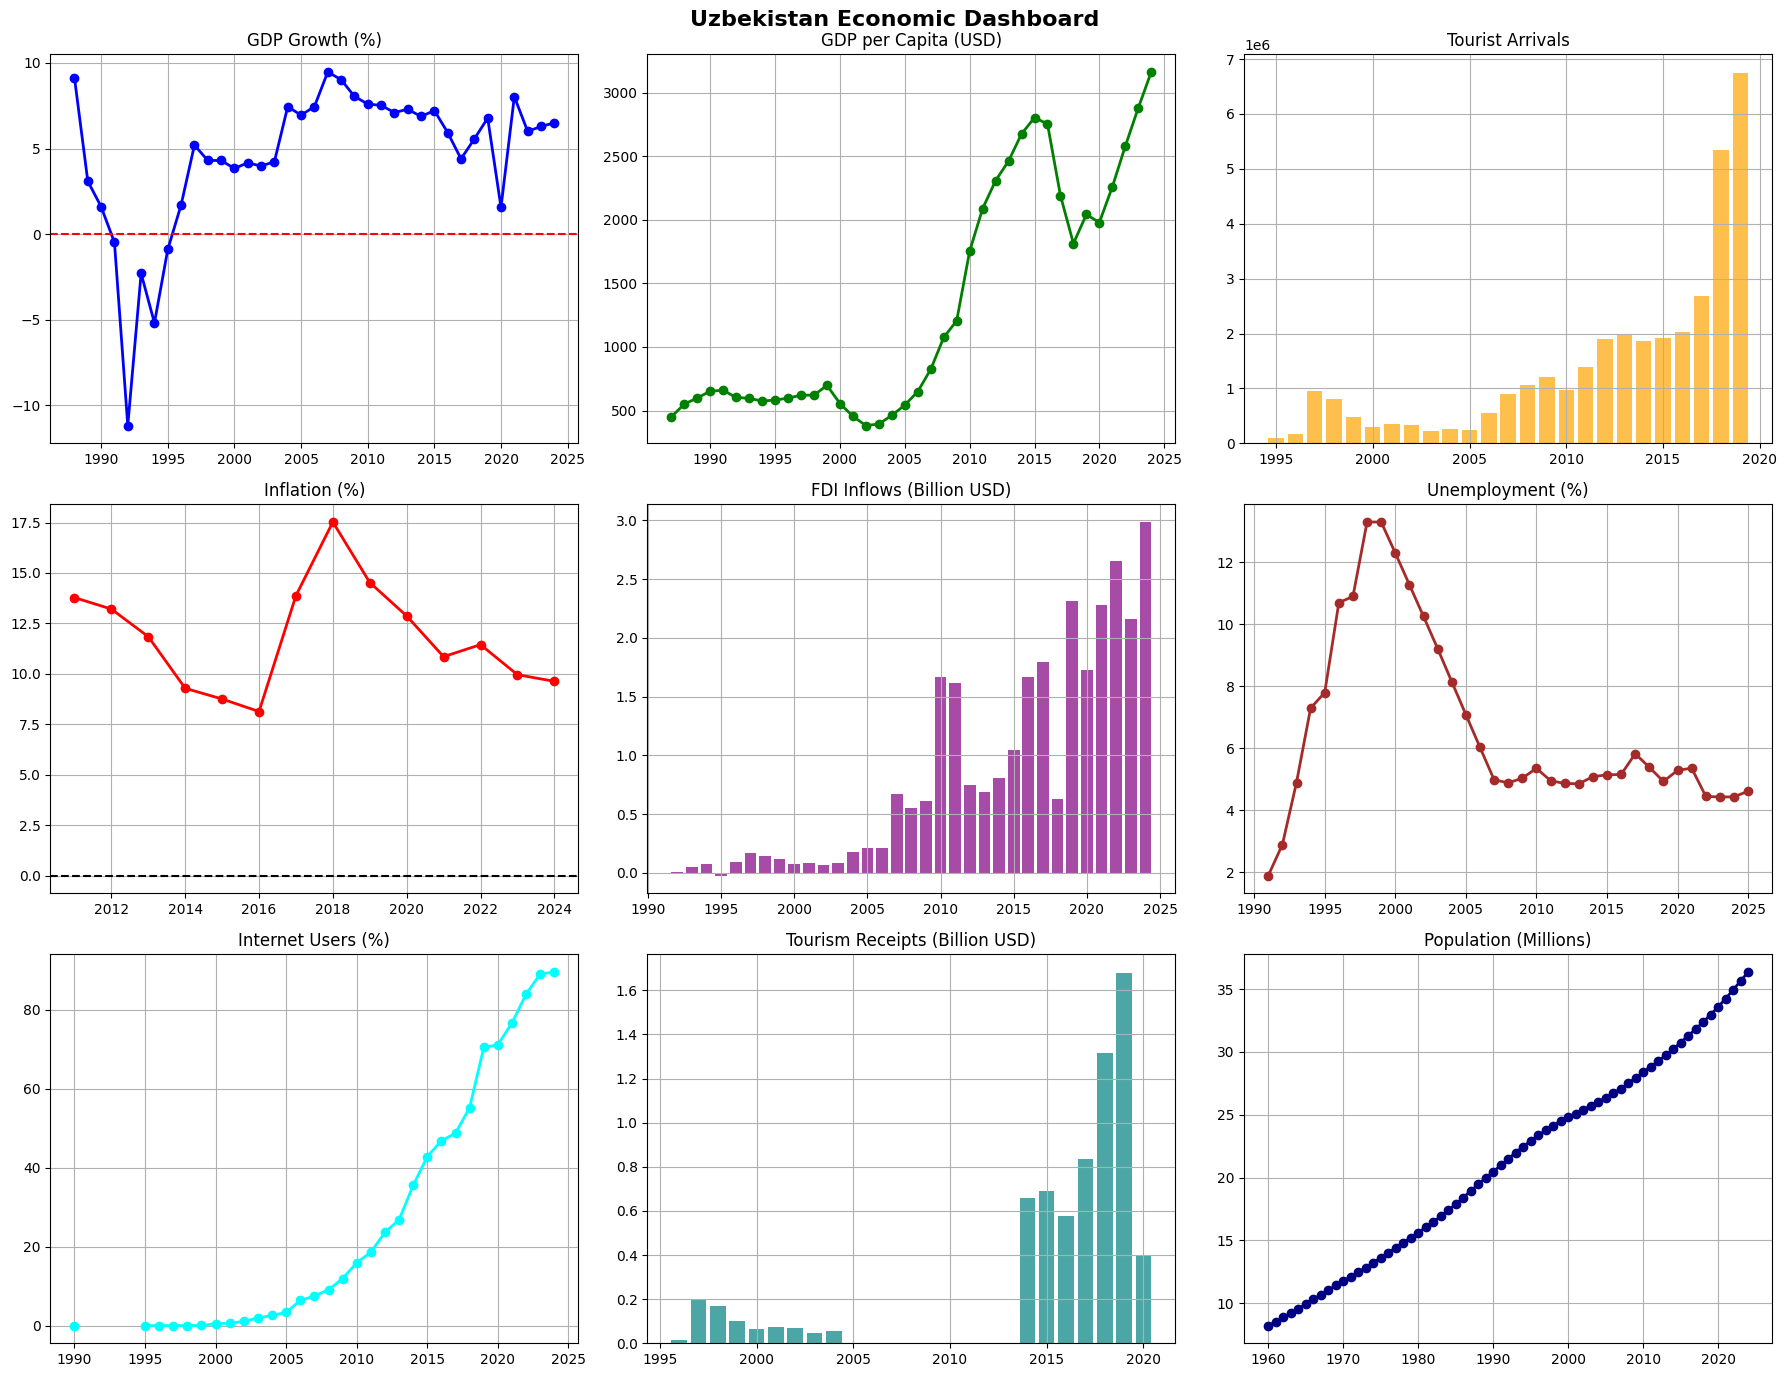

In [3]:
# ============================================
# 4. VISUALIZATIONS
# ============================================

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Uzbekistan Economic Dashboard', 
             fontsize=16, fontweight='bold')

# GDP Growth
axes[0,0].plot(uzb.index, uzb['gdp_growth_pct'], 
               color='blue', linewidth=2, marker='o')
axes[0,0].set_title('GDP Growth (%)')
axes[0,0].axhline(y=0, color='red', linestyle='--')
axes[0,0].grid(True)

# GDP per capita
axes[0,1].plot(uzb.index, uzb['gdp_per_capita_usd'], 
               color='green', linewidth=2, marker='o')
axes[0,1].set_title('GDP per Capita (USD)')
axes[0,1].grid(True)

# Tourist Arrivals
axes[0,2].bar(uzb.index, uzb['tourist_arrivals'], 
              color='orange', alpha=0.7)
axes[0,2].set_title('Tourist Arrivals')
axes[0,2].grid(True)

# Inflation
axes[1,0].plot(uzb.index, uzb['inflation_pct'], 
               color='red', linewidth=2, marker='o')
axes[1,0].set_title('Inflation (%)')
axes[1,0].axhline(y=0, color='black', linestyle='--')
axes[1,0].grid(True)

# FDI
axes[1,1].bar(uzb.index, uzb['fdi_inflows_usd']/1e9, 
              color='purple', alpha=0.7)
axes[1,1].set_title('FDI Inflows (Billion USD)')
axes[1,1].grid(True)

# Unemployment
axes[1,2].plot(uzb.index, uzb['unemployment_pct'], 
               color='brown', linewidth=2, marker='o')
axes[1,2].set_title('Unemployment (%)')
axes[1,2].grid(True)

# Internet Users
axes[2,0].plot(uzb.index, uzb['internet_users_pct'], 
               color='cyan', linewidth=2, marker='o')
axes[2,0].set_title('Internet Users (%)')
axes[2,0].grid(True)

# Tourism Receipts
axes[2,1].bar(uzb.index, uzb['tourism_receipts_usd']/1e9, 
              color='teal', alpha=0.7)
axes[2,1].set_title('Tourism Receipts (Billion USD)')
axes[2,1].grid(True)

# Population
axes[2,2].plot(uzb.index, uzb['population']/1e6, 
               color='navy', linewidth=2, marker='o')
axes[2,2].set_title('Population (Millions)')
axes[2,2].grid(True)

plt.tight_layout()
plt.savefig('../outputs/uzbekistan_economic_dashboard.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dashboard saved to outputs folder!")

FileNotFoundError: [Errno 2] No such file or directory: '../outputs/central_asia_comparison.png'

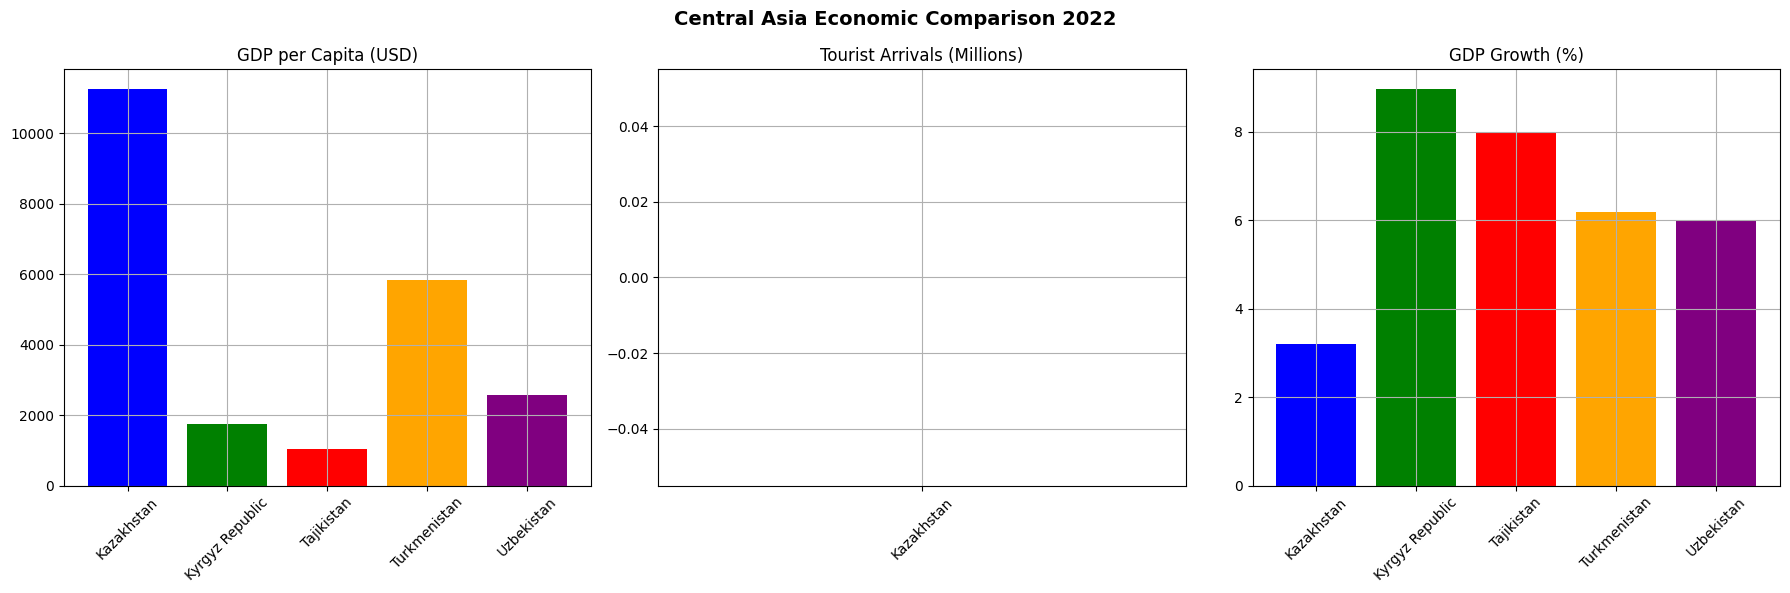

In [4]:
# ============================================
# 5. CENTRAL ASIA COMPARISON
# ============================================

central_asia = df.copy()
central_asia['date'] = pd.to_numeric(central_asia['date'])

# Latest year comparison
latest = central_asia[central_asia['date'] == 2022]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Central Asia Economic Comparison 2022', 
             fontsize=14, fontweight='bold')

# GDP per capita comparison
axes[0].bar(latest['country'], 
            latest['gdp_per_capita_usd'],
            color=['blue','green','red','orange','purple'])
axes[0].set_title('GDP per Capita (USD)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True)

# Tourist arrivals
axes[1].bar(latest['country'], 
            latest['tourist_arrivals']/1e6,
            color=['blue','green','red','orange','purple'])
axes[1].set_title('Tourist Arrivals (Millions)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True)

# GDP Growth
axes[2].bar(latest['country'], 
            latest['gdp_growth_pct'],
            color=['blue','green','red','orange','purple'])
axes[2].set_title('GDP Growth (%)')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(True)

plt.tight_layout()
plt.savefig('../outputs/central_asia_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Comparison chart saved!")